# 📘 S9_P4 — Le pipeline complet : régression avec PyTorch Lightning

> **Comment lire ce notebook.** Le code est **exactement celui que tu as écrit**. Je n'ai
> ajouté que des explications entre tes cellules. L'original est dans
> `01_Exercices_originaux/S9_P4_DL.ipynb`.

## 🎯 Le saut par rapport au S9_P3

Le S9_P3 était un atelier : tenseurs, autograd, une boucle à la main, des données jouet.
**Ici, c'est un vrai projet**, de bout en bout :

| Étape | Cellules | Ce que tu fais |
|---|---|---|
| 1️⃣ **Fabriquer** les données | 2 → 6 | une fonction non linéaire + du bruit |
| 2️⃣ **Séparer** train / validation | 7 | le vrai `train_test_split`, pas le même loader |
| 3️⃣ **Normaliser** | 8 → 11 | `StandardScaler` — la leçon du S9_P3 |
| 4️⃣ **Emballer** | 12 → 21 | tenseurs → `Dataset` → `DataLoader` |
| 5️⃣ **Modéliser** | 22 → 23 | un MLP à 2 couches cachées |
| 6️⃣ **Entraîner** | 24 → 26 | `CSVLogger` + `Trainer` |
| 7️⃣ **Lire les courbes** | 27 → 29 | train vs val : le surapprentissage |
| 8️⃣ **Évaluer** | 30 → 39 | `eval()`, `no_grad()`, MAE / RMSE / R² |

C'est **le squelette de tout projet de deep learning**. Change les données et le modèle, la
structure ne bouge pas.

## ✅ Ce que tu as corrigé depuis le S9_P3

Deux bugs du P3 ont disparu ici — compare, c'est la meilleure façon de les retenir :

| | S9_P3 | S9_P4 |
|---|---|---|
| `training_step` | ❌ pas de `return loss` | ✅ `return loss` |
| `configure_optimizers` | ❌ `pure_model.parameters()` | ✅ `self.parameters()` |

Il reste quelques pièges — je les signale au passage, chacun à sa cellule.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger

pl.seed_everything(32)


Seed set to 32


32

## 🧠 THÉORIE — Pourquoi fabriquer ses données ?

```python
y = np.sin(x1) + 0.5 * (x2 ** 2) + noise
```

Ce n'est pas de la triche, c'est de la **méthode**. Quand tu inventes les données, tu
connais **la vérité**. Donc si ton réseau échoue, tu sais que le problème vient du réseau —
jamais des données. Sur un vrai dataset, tu ne peux jamais trancher.

### Une fonction choisie exprès

| Terme | Forme | Pourquoi il est là |
|---|---|---|
| $\sin(x_1)$ | ondulation | **non linéaire** — une régression linéaire s'y casse les dents |
| $0.5\,x_2^2$ | parabole | **non linéaire**, et d'un autre type |
| $\varepsilon \sim \mathcal{N}(0;\,0{,}15)$ | bruit gaussien | le réel n'est jamais parfait |

Le bruit est **essentiel** : sans lui, un réseau assez gros atteindrait une erreur nulle et
tu n'apprendrais rien sur le surapprentissage. Ici, l'écart-type du bruit (0,15) est le
**plancher d'erreur** : aucun modèle, même parfait, ne peut faire mieux. Garde ce chiffre en
tête, il servira à juger ton RMSE à la fin.

### `rng = np.random.default_rng(32)`

La façon **moderne** de tirer de l'aléatoire avec NumPy (à préférer à `np.random.seed`).
La graine `32` rend tes 1200 points **identiques à chaque exécution** — même esprit que le
`random_state=32` que tu mets partout depuis S1.

In [3]:
# y = sin(x1) + 0.5 * x2 ^2 + noise
n_samples = 1200
rng = np.random.default_rng(32)
x1 = rng.uniform(-3.0, 3.0, size=n_samples)
x2 = rng.uniform(-2.0, 2.0, size=n_samples)
noise = rng.normal(loc=0.0, scale=0.15, size=n_samples)

y = np.sin(x1) +  0.5 * (x2 ** 2) + noise

### Les formes, encore et toujours

```python
X = np.column_stack([x1, x2]).astype(np.float32)   # (1200, 2)
y = y.reshape(-1, 1).astype(np.float32)            # (1200, 1)
```

`column_stack` colle tes deux vecteurs `(1200,)` côte à côte en une matrice
`(1200, 2)` = **(échantillons, features)**. Le `reshape(-1, 1)` fait passer `y` de `(1200,)`
à `(1200, 1)` — PyTorch veut une colonne, pas un vecteur plat.

### ⚠️ `.astype(np.float32)` n'est pas cosmétique

NumPy travaille en `float64` par défaut, **PyTorch en `float32`**. Si tu ne convertis pas, tu
récoltes plus tard :

```
RuntimeError: expected scalar type Float but found Double
```

Le faire ici, une fois, t'évite le problème partout ensuite. Bonus : deux fois moins de
mémoire, et les GPU sont bien plus rapides en `float32`.

In [4]:
X = np.column_stack([x1, x2]).astype(np.float32)
y = y.reshape(-1, 1).astype(np.float32)
print(f"X Shape {X.shape} Y Shape {y.shape}")

X Shape (1200, 2) Y Shape (1200, 1)


In [5]:
data = pd.DataFrame({"x1": X[:,0], "x2": X[:,1], "y": y[:,0]})

### 👀 Première vue : 2D avec la couleur pour z

`hue="y"` encode la cible en **couleur**. Tu devrais deviner la structure : la couleur varie
en vagues selon `x1` (le sinus) et s'assombrit aux extrémités de `x2` (la parabole, qui est
symétrique — elle monte des deux côtés).

<Axes: xlabel='x1', ylabel='x2'>

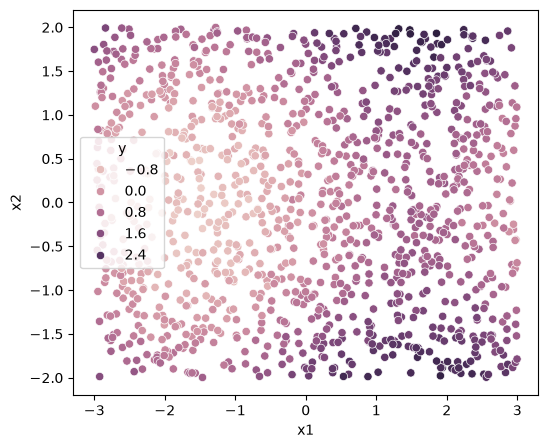

In [6]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=data, x="x1", y="x2", hue="y")

### 👀 Deuxième vue : la 3D, beaucoup plus parlante

`plotly` est interactif : **fais tourner la surface à la souris**. Tu verras la tôle ondulée
— la vague du sinus le long de `x1`, la vallée parabolique le long de `x2`.

**Regarde bien cette forme.** C'est *ça* que ton réseau doit apprendre à reproduire. Aucun
plan ne peut l'épouser : voilà pourquoi une régression linéaire échouerait, et pourquoi il
faut des ReLU.

> 💡 **Détail :** ton `fig = plt.figure(figsize=(10,5))` ne sert à rien — la ligne suivante
> réassigne `fig` avec la figure plotly. La figure matplotlib est créée puis jetée
> aussitôt (c'est elle qui produit le `<Figure size 1000x500 with 0 Axes>` vide dans la
> sortie). matplotlib et plotly sont deux mondes séparés.

In [7]:
import plotly.express as px
fig = plt.figure(figsize=(10,5))
fig = px.scatter_3d(data, x="x1", y="x2", z="y", opacity=0.7)
fig.update_traces(marker_size=2)

<Figure size 1000x500 with 0 Axes>

## 🧠 THÉORIE — Le vrai `train_test_split`

```python
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
```

**La différence majeure avec le S9_P3**, où tu passais le même loader en train et en
validation. Ici : 960 points pour apprendre, 240 que le modèle **ne verra jamais**
pendant l'entraînement.

**Pourquoi c'est non négociable :** un modèle assez gros peut *mémoriser* ses données
d'entraînement. Son erreur y sera excellente et il sera nul sur du neuf. Le seul moyen de
s'en apercevoir, c'est de le tester sur des données qu'il n'a jamais vues.

C'est exactement le même `train_test_split` que depuis S1 — **rien ne change en deep
learning**.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples {len(X_train)} Val Samples {len(X_val)}")

Training samples 960 Val Samples 240


## 🧠 THÉORIE — `StandardScaler` : la leçon du S9_P3

Souviens-toi de `TinyDataset2` : des `x` jusqu'à 100, et un entraînement qui partait en
vrille. Voilà le remède.

$$z = \frac{x - \mu}{\sigma}$$

Chaque colonne est recentrée sur 0 avec un écart-type de 1.

**Pourquoi les réseaux y sont si sensibles :** les poids sont initialisés autour de zéro et
le gradient est *proportionnel à l'entrée*. Une feature à 100 produit des gradients 100 fois
plus gros qu'une feature à 1 — le réseau ne corrige plus que celle-là, et le `lr` ne peut
pas convenir aux deux à la fois.

### On normalise aussi `y` ici

Moins courant, mais cohérent : la loss MSE reste dans une plage raisonnable. **Conséquence à
ne pas oublier** : tes prédictions sortiront *normalisées*, il faudra les ramener dans le
monde réel avec `inverse_transform` (cellule 31). C'est pour ça que `y_scaler` est gardé dans
une variable.

### 🔴 LE BUG à connaître — `fit_transform` sur la validation

```python
X_train_scaled = x_scaler.fit_transform(X_train)   # ✅ correct
X_val_scaled   = x_scaler.fit_transform(X_val)     # 🔴 devrait etre .transform(X_val)
```

| Méthode | Ce qu'elle fait |
|---|---|
| `fit_transform` | **calcule** μ et σ **sur ces données**, puis normalise |
| `transform` | réutilise le μ et le σ **déjà appris** |

En appelant `fit_transform` sur la validation, tu **écrases** le μ/σ du train et tu
normalises la validation avec ses **propres** statistiques. Deux dégâts :

1. **Fuite de données** *(data leakage)* — ton preprocessing a « regardé » la validation. En
   production, tu n'auras jamais les statistiques des données futures.
2. **Deux échelles différentes** — le modèle apprend dans un repère et est évalué dans un
   autre. Tes métriques finales sont fausses, en général trop optimistes.

**La règle, valable pour tout preprocessing :** `fit` **uniquement** sur le train,
`transform` partout ailleurs.

```python
X_val_scaled = x_scaler.transform(X_val).astype(np.float32)
y_val_scaled = y_scaler.transform(y_val).astype(np.float32)
```

> Ici les deux jeux viennent de la même distribution, donc μ et σ sont proches et les dégâts
> restent limités. **Sur des vraies données, ça peut fausser complètement tes résultats.**

In [9]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = x_scaler.fit_transform(X_val).astype(np.float32)

y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)
y_val_scaled = y_scaler.fit_transform(y_val).astype(np.float32)

print(f"BEFORE: {X_train.mean()} - {X_train.std()} - {y_train.mean()} - {y_train.std()}")


BEFORE: -0.007744939997792244 - 1.4703361988067627 - 0.6995208859443665 - 0.9720731973648071


### 💡 Le label ment (petit détail)

Ta cellule précédente affiche `BEFORE:` avec `X_train` (les données brutes) — logique. Mais
**celle-ci affiche aussi `BEFORE:`** alors qu'elle montre `X_train_scaled`, c'est-à-dire
l'**après**. Copier-coller.

Le contenu, lui, est parfait et prouve que le scaler fonctionne :

| | moyenne | écart-type |
|---|---|---|
| avant | ≈ -0,008 | ≈ 1,47 |
| après | ≈ 1,4e-08 → **0** | **1,0000** |

Le `1.4e-08` au lieu d'un zéro pur, c'est la précision du `float32`. Normal, et sans
conséquence.

In [10]:
print(f"BEFORE: {X_train_scaled.mean()} - {X_train_scaled.std()} - {y_train_scaled.mean()} - {y_train_scaled.std()}")

BEFORE: -1.9868215961338365e-09 - 1.0 - 3.1789145538141383e-08 - 1.0


In [11]:
x_scaler

StandardScaler()

### 💡 Cette cellule trace les **mauvaises** données

Regarde bien :

```python
data_scaled = pd.DataFrame({"x1": X_train_scaled[:,0], ...})   # tu le construis...
fig = px.scatter_3d(data, x="x1", y="x2", z="y", opacity=0.7)  # ...et tu traces `data` !
```

Tu fabriques `data_scaled` et tu ne t'en sers pas : le graphe affiche `data`, les données
**non normalisées** — le même graphe que tout à l'heure. Il faudrait
`px.scatter_3d(data_scaled, ...)`.

Sans gravité (la normalisation ne déforme pas la *forme*, elle change juste les
graduations), mais si ton but était de *voir* l'effet du scaling, c'est raté.

In [12]:
import plotly.express as px
fig = plt.figure(figsize=(10,5))
data_scaled = pd.DataFrame({"x1": X_train_scaled[:,0], "x2": X_train_scaled[:,1], "y": y_train_scaled[:,0]})
fig = px.scatter_3d(data, x="x1", y="x2", z="y", opacity=0.7)
fig.update_traces(marker_size=2)

<Figure size 1000x500 with 0 Axes>

## 🧠 THÉORIE — NumPy → tenseurs

```python
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
```

Le passage de frontière : `sklearn` parle NumPy, PyTorch parle tenseurs. Le `dtype=` est
redondant ici (tu as déjà fait `.astype(np.float32)` plus haut) mais **le redire ne coûte
rien et documente l'intention**.

> 💡 **Culture :** `torch.tensor(...)` **copie** les données. `torch.from_numpy(...)` partage
> la mémoire avec le tableau NumPy — plus rapide, mais modifier l'un modifie l'autre. Pour
> apprendre, la copie est plus sûre.

In [13]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)

In [14]:
print(y_train_tensor.shape)

torch.Size([960, 1])


## 🧠 THÉORIE — Ton `Dataset`, version générique

Compare avec le S9_P3 : là-bas, `TinyDataset` fabriquait ses données *dans* `__init__`. Ici,
`RegressionDataset` **reçoit** X et y en arguments. C'est bien mieux : **une seule classe**
sert pour le train et pour la validation.

```python
def __getitem__(self, index):
    x = self.X[index, :]    # toutes les features de la ligne `index` -> shape (2,)
    y = self.y[index]       # la cible                                 -> shape (1,)
    return x, y
```

### ⚠️ La forme de `y` doit coller à celle du modèle

`self.y[index]` renvoie `(1,)` — un vecteur d'un élément. Ton `forward` retourne
`self.model(x)`, donc `(1,)` aussi. **Les deux concordent**, la MSE est correcte.

> 🔴 **Le piège si tu changes l'un sans l'autre.** Si tu écrivais `self.y[index, 0]` (un
> scalaire, forme `()`), le batch de cibles deviendrait `(32,)` alors que les prédictions
> restent `(32, 1)`. PyTorch **ne planterait pas** : il ferait du *broadcasting*, comparerait
> tout le monde avec tout le monde en `(32, 32)`, et ta loss serait silencieusement fausse.
> Tu récolterais juste un warning discret :
> ```
> UserWarning: Using a target size (torch.Size([32])) that is different to the input size
> (torch.Size([32, 1]))
> ```
> **Ne l'ignore jamais.** C'est le bug le plus vicieux du deep learning : ça tourne, ça
> affiche une perte, et ça n'apprend rien de bon.

In [15]:
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        x = self.X[index, :]
        y = self.y[index]
        return x, y

In [16]:
train_dataset = RegressionDataset(X_train_tensor, y_train_tensor)
val_dataset = RegressionDataset(X_val_tensor, y_val_tensor)

In [17]:
len(val_dataset)

240

In [18]:
val_dataset[10]

(tensor([1.1953, 0.5955]), tensor([0.3945]))

## 🧠 THÉORIE — Deux loaders, deux réglages

```python
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
```

| | `shuffle` | Pourquoi |
|---|---|---|
| **train** | `True` | mélanger à chaque epoch évite que le réseau apprenne **l'ordre** |
| **val** | `False` | inutile de mélanger — et on veut un résultat reproductible |

960 échantillons ÷ 32 = **30 batches par epoch**. Retiens ce chiffre : c'est le `30/30` que
tu verras défiler dans la barre de progression.

In [19]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

### 🔍 Le réflexe qui sauve : inspecter un batch

```python
first_batch_x, first_batch_y = next(iter(train_loader))
```

`iter()` ouvre le loader, `next()` en tire **un** batch. Deux lignes qui t'évitent de lancer
un entraînement pour découvrir au bout de 3 minutes que tes formes sont fausses.

Tu dois lire `torch.Size([32, 2])` et `torch.Size([32, 1])` : 32 échantillons, 2 features,
1 cible. **Prends ce réflexe avant chaque `fit`.**

In [20]:
first_batch_x, first_batch_y = next(iter(train_loader))

In [21]:
print(first_batch_x.shape, first_batch_y.shape)

torch.Size([32, 2]) torch.Size([32, 1])


In [22]:
print(first_batch_x, first_batch_y)

tensor([[-1.6587,  1.4391],
        [ 0.2032, -1.5935],
        [-1.2833, -0.3008],
        [ 1.6376, -1.2050],
        [-1.2578, -0.7943],
        [ 1.4543,  0.7857],
        [-0.3310, -0.7825],
        [-0.4872,  1.5247],
        [ 0.5830,  1.5846],
        [-1.4687, -1.3504],
        [ 0.3942,  1.7502],
        [ 0.8931, -0.3552],
        [-0.6953,  1.3467],
        [ 0.6331, -0.6920],
        [ 0.1304, -1.0093],
        [-0.9267, -1.6375],
        [-1.0674, -0.0341],
        [-1.0620, -1.3861],
        [-1.7278, -0.8349],
        [ 1.6438,  1.7243],
        [-0.0817, -1.2306],
        [ 1.2812,  1.2477],
        [ 0.9191,  0.0053],
        [-0.9989, -0.8526],
        [ 1.7032,  1.1855],
        [ 1.5428, -1.3634],
        [-0.8655, -0.4549],
        [ 0.7223,  1.7001],
        [-1.4813, -0.8262],
        [-1.1748, -1.4095],
        [-0.3021, -0.6673],
        [ 1.0490, -0.3293]]) tensor([[ 0.3592],
        [ 1.5767],
        [-1.4962],
        [ 0.8267],
        [-1.4082],
        

## 🧠 THÉORIE — Le MLP : ton premier vrai réseau

**MLP** = *Multi-Layer Perceptron*, le réseau de neurones classique.

```python
nn.Sequential(nn.Linear(2, 32), nn.ReLU(),
              nn.Linear(32, 32), nn.ReLU(),
              nn.Linear(32, 1))
```

`nn.Sequential` est un raccourci : il enchaîne les couches dans l'ordre, tu n'écris pas le
`forward` à la main. Compare avec le `TinyNetworks` du S9_P3, où tu déclarais chaque couche
puis les appelais une par une — même résultat, moins de lignes.

### L'architecture, couche par couche

| Couche | Forme | Paramètres |
|---|---|---|
| `Linear(2, 32)` | 2 → 32 | 2×32 + 32 = **96** |
| `ReLU` | — | 0 |
| `Linear(32, 32)` | 32 → 32 | 32×32 + 32 = **1056** |
| `ReLU` | — | 0 |
| `Linear(32, 1)` | 32 → 1 | 32×1 + 1 = **33** |
| | | **1185 ≈ 1,2 K** |

C'est le `1.2 K` que Lightning affiche dans son tableau au lancement. **Deux** couches
cachées cette fois (le S9_P3 n'en avait qu'une) : il faut cette profondeur pour épouser à la
fois le sinus et la parabole.

### 🎯 Pourquoi pas de ReLU à la fin ?

Parce que **c'est une régression**. La ReLU écrase les négatifs à zéro — ton modèle serait
incapable de prédire une valeur négative, alors que ton `y` en contient (le sinus descend
sous zéro). **La dernière couche d'une régression est toujours nue.**

> C'est la différence avec une classification, où tu finirais par une sigmoïde (binaire) ou
> un softmax (multiclasse). La règle : **la dernière couche dépend du problème, pas du
> réseau.**

### Les trois méthodes Lightning

| Méthode | Ce que tu écris | ✅ chez toi |
|---|---|---|
| `training_step` | forward + loss + **`return loss`** | ✅ le `return` est là |
| `validation_step` | pareil, sans gradient | ✅ (pas de `return` nécessaire) |
| `configure_optimizers` | **`self.parameters()`** | ✅ le bon réseau |

**Les deux bugs du S9_P3 sont corrigés.** C'est ce qui fait que ce notebook apprend vraiment.

### `on_step=False, on_epoch=True`

Tu ne logues pas chaque batch, mais **la moyenne de l'epoch**. Exactement le
`average_total_error` que tu calculais à la main dans le S9_P3 — Lightning le fait pour toi.
Des courbes bien plus lisibles.

In [23]:
class MLPRegressor(pl.LightningModule):
    def __init__(self, input_dim=2, hidden_dim=32, learning_rate=0.01):
        super().__init__()
        self.save_hyperparameters()

        self.model = nn.Sequential(nn.Linear(input_dim, hidden_dim), 
                                   nn.ReLU(), 
                                   nn.Linear(hidden_dim, hidden_dim),
                                   nn.ReLU(),
                                   nn.Linear(hidden_dim, 1))
        
        self.loss_fn = nn.MSELoss()
        self.learning_rate = learning_rate

    def forward(self, x):
            return self.model(x)
        
    def training_step(self, batch, batch_idx):
        x, y = batch
        predictions = self(x)
        loss = self.loss_fn(predictions, y)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        predictions = self(x)
        loss = self.loss_fn(predictions, y)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
    
    
    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate)
        return optimizer
        

### Le learning rate : 1e-3 et pas 0.01

Ton `__init__` a `learning_rate=0.01` par défaut, mais tu instancies avec **`1e-3`** — dix
fois moins. C'est le réglage n°1 du deep learning :

| `lr` | Effet |
|---|---|
| trop grand | la perte oscille ou explose (`NaN`) — tu sautes par-dessus le minimum |
| trop petit | ça descend, mais il te faut 10× plus d'epochs |
| **bien réglé** | descente franche puis plateau |

> ⚠️ Ton `configure_optimizers` utilise **SGD**. Avec SGD, `1e-3` sur 200 epochs, c'est
> prudent — la descente sera lente. Si tes courbes n'ont pas fini de descendre au bout des
> 200 epochs, ce n'est pas un bug : c'est le `lr`. **Adam** (`torch.optim.Adam`) adapte le
> pas tout seul et converge en général bien plus vite sur ce genre de problème. Essaie les
> deux, compare les courbes — c'est l'expérience la plus instructive du notebook.

In [24]:
model = MLPRegressor(input_dim=2, hidden_dim=32, learning_rate=1e-3)

## 🧠 THÉORIE — `CSVLogger` : garder une trace

```python
logger = CSVLogger(save_dir="lightning_logs", name="basic_mlp_regressor")
```

Le S9_P3 avait `logger=False` : les pertes défilaient et étaient perdues. Ici, Lightning
**écrit chaque métrique dans un CSV** que tu reliras pour tracer tes courbes.

```
lightning_logs/basic_mlp_regressor/
├── version_0/    ← ton 1er fit
│   ├── metrics.csv
│   └── hparams.yaml
├── version_1/    ← ton 2e fit
└── version_2/    ← ton 3e fit
```

### ⚠️ Un nouveau `version_N` à **chaque** `fit`

Lightning **n'écrase jamais** un run : il incrémente. C'est une qualité (tu gardes ton
historique) qui devient un piège à la cellule 27 — j'y reviens.

Le `hparams.yaml` contient ce que `save_hyperparameters()` a capturé : ton `hidden_dim`, ton
`learning_rate`. Six mois plus tard, tu sauras quels réglages ont produit quelle courbe.

In [25]:
logger = CSVLogger(save_dir="lightning_logs", name="basic_mlp_regressor")

### Le `Trainer`

| Argument | Effet |
|---|---|
| `max_epochs=200` | 200 passages × 30 batches = **6000 mises à jour** |
| `accelerator="auto"` | GPU si dispo — **aucun `.to(device)` à écrire** |
| `logger=logger` | branche le `CSVLogger` |
| `enable_checkpointing=False` | ne sauvegarde pas les poids |
| `log_every_n_steps=5` | écrit une ligne tous les 5 batches |

### 🔴 Rappel : le `Trainer` est à usage unique

Une fois `max_epochs` atteint, rappeler `.fit()` sur le **même** objet ne fait **rien** :
sortie en `0.0s`, pas de barre de progression, juste le résumé du modèle et
`` `Trainer.fit` stopped: `max_epochs=200` reached ``.

**Pour réentraîner : réexécute cette cellule-ci**, pas seulement le `.fit()`.

### 💡 Sur ce modèle, le GPU est plus lent que le CPU

Mesuré sur ta machine, ce notebook exact :

| | par epoch | 200 epochs |
|---|---|---|
| **CPU** | 0,048 s | **~10 s** |
| **GPU** Radeon 880M | 0,127 s | **~25 s** |

Ce n'est pas une anomalie. 1,2 K paramètres et des batches de 32, c'est **trop petit pour un
GPU** : le temps part en lancement de kernels et en transferts, pas en calcul. Le GPU ne
gagne que quand tu le satures — gros batches, gros modèles, convolutions sur images.

**Retiens la règle : un GPU ne va pas vite, il va large.**

In [26]:
trainer = pl.Trainer(max_epochs=200,
                    accelerator="auto", 
                    devices="auto", 
                    logger=logger, 
                    enable_checkpointing=False,
                    log_every_n_steps=5)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### ▶️ L'entraînement

> ## 🔴 `val_dataloaders=train_loader` — la vraie erreur du notebook
>
> ```python
> trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=train_loader)
> #                                                                  ^^^^^^^^^^^^
> ```
>
> Tu as créé un `val_loader` propre à la cellule 18… et tu passes `train_loader` **deux
> fois**. Donc **tu valides sur tes données d'entraînement**.
>
> **Ce que ça détruit :** ta `val_loss` n'est qu'une copie de ta `train_loss`. Or la
> validation ne sert **qu'à une chose** : repérer le moment où le modèle arrête de
> généraliser et commence à mémoriser. Avec `val = train`, les deux courbes descendent
> gentiment ensemble et **tu ne peux pas voir le surapprentissage**. Tu as construit ton
> détecteur d'incendie et tu l'as branché sur la mauvaise pièce.
>
> ```python
> trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
> ```
>
> **Corrige-le et relance** : la cellule 29 devient enfin lisible, et c'est tout l'intérêt
> du notebook. Plus tu montes `max_epochs`, plus ça compte.

In [27]:
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=train_loader)

You are using a CUDA device ('AMD Radeon(TM) 880M Graphics') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode  | FLOPs
-------------------------------------------------------
0 | model   | Sequential | 1.2 K  | train | 0    
1 | loss_fn | MSELoss    | 0      | train | 0    
-------------------------------------------------------
1.2 K     Trainable params
0         Non-trainable params
1.2 K     Total params
0.005     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\kirit\Documents\Projets\pytorch-rocm\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
c:\Users\kirit\Documents\Projets\pytorch-rocm\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\kirit\Documents\Projets\pytorch-rocm\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


### 🔴 `version_2` en dur — le piège du CSVLogger

```python
metrics = pd.read_csv("lightning_logs/basic_mlp_regressor/version_2/metrics.csv")
```

Souviens-toi : Lightning crée un **nouveau `version_N` à chaque `fit`**. Ce `version_2` était
juste quand tu l'as écrit. Mais dès que tu relances l'entraînement, tu produis `version_3`…
et cette cellule continue de lire `version_2`. **Tu traceras les courbes d'un ancien run
sans t'en apercevoir.**

Symptôme classique : « j'ai changé mon learning rate mais la courbe est identique ». Normal,
tu lis l'ancien CSV.

**La correction robuste** — le logger connaît son propre dossier :

```python
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
```

`logger.log_dir` pointe **toujours** sur le run qui vient de tourner. Plus jamais de numéro à
mettre à jour à la main.

> 💡 Sur Colab, `version_0` tombe juste à chaque fois — la machine est neuve à chaque
> session. C'est en local que ça dérape.

In [38]:
metrics = pd.read_csv("lightning_logs/basic_mlp_regressor/version_2/metrics.csv")

### Lire le CSV : pourquoi ce `dropna` ?

```python
train_loss = metrics.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].last()
```

Ouvre `metrics` (la cellule l'affiche) et tu comprendras : le CSV est **en escalier**.
Lightning écrit les métriques de train et de validation à des moments différents, donc
chaque ligne n'a qu'une colonne remplie et l'autre à `NaN` :

| epoch | step | train_loss | val_loss |
|---|---|---|---|
| 0 | 4 | 0.9812 | `NaN` |
| 0 | 29 | `NaN` | 0.9903 |
| 1 | 34 | 0.9721 | `NaN` |

- `dropna(subset=["train_loss"])` → ne garde que les lignes qui ont un train_loss
- `groupby("epoch").last()` → une seule valeur par epoch (la dernière écrite)

Tu obtiens deux séries propres indexées par epoch, prêtes à tracer.

In [39]:
metrics
train_loss = metrics.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].last()
val_loss = metrics.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].last()

## 📈 LA cellule à savoir lire

Deux courbes, et tout le diagnostic d'un entraînement tient dans leur écart :

| Ce que tu vois | Diagnostic | Quoi faire |
|---|---|---|
| les deux descendent, collées | 😀 **ça apprend bien** | tu peux entraîner plus longtemps |
| train ↓ , **val qui remonte** | 🔴 **surapprentissage** | arrête plus tôt, ou régularise |
| les deux **plates et hautes** | 🔴 **ça n'apprend pas** | `lr` trop petit, ou un bug |
| en **dents de scie** | ⚠️ `lr` trop grand | divise-le par 10 |
| val **sous** train | 🤨 suspect | tes deux jeux ne sont pas comparables |

**Le point de croisement** — là où la val remonte pendant que le train descend — c'est le
moment où ton modèle arrête d'apprendre le *signal* et commence à apprendre le *bruit*.
C'est là qu'il fallait s'arrêter. (Lightning sait le faire tout seul :
`EarlyStopping(monitor="val_loss", patience=10)`.)

> 🔴 **Mais pas dans ce notebook.** Avec `val_dataloaders=train_loader`, tes deux courbes
> sont **la même courbe** — tu ne verras jamais de croisement. Corrige la cellule 26 pour que
> ce graphe veuille dire quelque chose.

In [40]:
px.line(pd.DataFrame({"train": train_loss, "val": val_loss}))

## 🧠 THÉORIE — Évaluer proprement : deux réflexes obligatoires

```python
model.eval()
with torch.no_grad():
    val_predictions_scaled = model(X_val_tensor).cpu().numpy()
```

Ces deux lignes sont **des réflexes**, à écrire systématiquement avant toute prédiction.

| Ligne | Ce qu'elle fait | Si tu l'oublies |
|---|---|---|
| `model.eval()` | bascule en mode évaluation | Dropout et BatchNorm restent en mode *train* → **prédictions fausses** |
| `torch.no_grad()` | coupe la construction du graphe | mémoire gaspillée, calcul plus lent |

### `eval()` : pourquoi ça compte (même si ici ça ne change rien)

Certaines couches **se comportent différemment** à l'entraînement et en prédiction :

- **Dropout** éteint des neurones au hasard pendant l'entraînement — il faut *tous* les
  rallumer pour prédire
- **BatchNorm** utilise les statistiques du batch en train, et des moyennes accumulées en eval

Ton MLP n'a **ni l'un ni l'autre**, donc `eval()` ne change rien *ici*. **Écris-le quand
même** : le jour où tu ajoutes un Dropout et que tu as oublié le réflexe, tu chercheras des
heures pourquoi tes prédictions sont bruitées.

### `no_grad()` : tu ne vas pas dériver

L'autograd construit son graphe à chaque forward *au cas où* tu appellerais `.backward()`.
En prédiction, tu ne le feras jamais. `no_grad()` lui dit de ne rien enregistrer : moins de
mémoire, plus de vitesse.

### `.cpu()` avant `.numpy()`

NumPy vit en RAM et ne sait rien des GPU. Un tenseur qui serait resté sur la carte
provoquerait `TypeError: can't convert cuda tensor to numpy`. `.cpu()` le rapatrie d'abord.
Si le tenseur est déjà en RAM, c'est un no-op gratuit — donc **écris-le toujours**.

In [31]:
model.eval()
with torch.no_grad():
    val_predictions_scaled = model(X_val_tensor).cpu().numpy()

### 🔑 `inverse_transform` : revenir dans le monde réel

```python
val_prediction = y_scaler.inverse_transform(val_predictions_scaled)
```

**La cellule qu'on oublie tout le temps.** Ton modèle a appris sur un `y` normalisé : il
prédit donc des valeurs normalisées, du genre `-0,42`. Ça ne veut rien dire.

$$y_{\text{réel}} = z \times \sigma + \mu$$

`inverse_transform` applique cette formule avec le μ et le σ mémorisés par `y_scaler` au
`fit_transform`. **C'est pour ça qu'il fallait garder le scaler dans une variable.**

> ⚠️ Si tu compares un `y` prédit normalisé à un `y_val` réel, tes MAE et RMSE sont
> **absurdes** sans que rien ne plante. Ici tu fais bien la conversion — et tu compares au
> `y_val` brut. ✅

In [32]:
val_prediction = y_scaler.inverse_transform(val_predictions_scaled)


## 🧠 THÉORIE — Les métriques : MAE, RMSE, R²

Les mêmes qu'en S1. Rien ne change parce que c'est du deep learning.

| Métrique | Formule | Se lit |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum \lvert \hat{y}-y \rvert$ | l'erreur moyenne, **dans l'unité de y** |
| **RMSE** | $\sqrt{\frac{1}{n}\sum (\hat{y}-y)^2}$ | idem, mais **punit les grosses erreurs** |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | la part de variance expliquée (1 = parfait) |

**RMSE > MAE toujours.** L'écart entre les deux te renseigne : proches = erreurs homogènes ;
très écartés = quelques grosses erreurs isolées.

### 🎯 Comment juger ton résultat

Deux repères, et ils sont dans le notebook :

1. **Le plancher de bruit** = `0,15` (le `scale` de ton `rng.normal`). C'est le mieux qu'un
   modèle *parfait* puisse faire. Un RMSE proche de 0,15 = excellent.
2. **`y_val.std()`** — que tu affiches juste après, et c'est malin. C'est l'erreur d'un
   modèle **stupide** qui prédirait toujours la moyenne. **Ton RMSE doit être nettement en
   dessous**, sinon ton réseau ne sert à rien.

In [33]:
MAE = mean_absolute_error(val_prediction,y_val)

In [34]:
MAE

0.326007217168808

In [35]:
y_val.std()

np.float32(0.89308804)

In [36]:
RSME = np.sqrt(mean_squared_error(val_prediction,y_val))

In [37]:
RSME

np.float64(0.39803866451881226)

### 🔴 LE BUG DE CETTE CELLULE — les arguments de `r2_score` sont inversés

```python
r2 = r2_score(val_prediction, y_val)
#             ^^^^^^^^^^^^^^  ^^^^^  inverses !
```

La signature scikit-learn est **`r2_score(y_true, y_pred)`** — la **vérité d'abord**. Tu as
mis la prédiction en premier.

### Pourquoi ça passe inaperçu pour MAE et RMSE, mais pas pour R²

Regarde tes deux cellules précédentes : `mean_absolute_error(val_prediction, y_val)` et
`mean_squared_error(val_prediction, y_val)` sont **aussi inversées**… et pourtant elles
donnent le **bon résultat**. Pourquoi ?

Parce qu'elles sont **symétriques** : $\lvert a-b \rvert = \lvert b-a \rvert$ et
$(a-b)^2 = (b-a)^2$. L'ordre n'a aucune importance.

**R² ne l'est pas :**

$$R^2 = 1 - \frac{\sum (y_{\text{true}} - y_{\text{pred}})^2}{\sum (y_{\text{true}} - \overline{y_{\text{true}}})^2}$$

Le numérateur est symétrique, mais **le dénominateur utilise la variance du _premier_
argument**. Inverse les arguments, et tu divises par la variance de tes *prédictions* au lieu
de celle de la *vérité*. **Ce n'est plus le même nombre.**

**Mesuré** (500 points, un modèle correct) :

| Appel | R² |
|---|---|
| `r2_score(y_true, y_pred)` ✅ | **0.8233** |
| `r2_score(y_pred, y_true)` 🔴 | **0.7735** |

Presque 5 points d'écart. Et le signe de l'erreur dépend du modèle : ça peut aussi te
**surestimer**.

```python
r2 = r2_score(y_val, val_prediction)   # la verite en premier, toujours
```

> 📌 **Le réflexe à prendre :** en scikit-learn, **toutes** les métriques prennent
> `(y_true, y_pred)` dans cet ordre. Prends l'habitude de le respecter **même quand la
> métrique est symétrique** — le jour où tu passes à une métrique qui ne l'est pas, tu ne te
> feras pas avoir.

In [45]:
r2 = r2_score(val_prediction, y_val)

In [46]:
r2

0.7325513362884521

### 📈 Le graphique de vérité — prédit vs réel

Le dernier réflexe d'évaluation, et le plus parlant.

**Comment le lire :** chaque point est un échantillon de validation. En abscisse sa vraie
valeur, en ordonnée ce que ton modèle a prédit.

**Un modèle parfait mettrait tous les points sur la diagonale $y = x$.**

| Ce que tu vois | Ce que ça dit |
|---|---|
| nuage serré sur la diagonale | 😀 bon modèle |
| nuage large mais centré | erreur homogène — regarde le RMSE |
| **courbé** (banane) | 🔴 le modèle rate une non-linéarité |
| **aplati** aux extrêmes | 🔴 il n'ose pas les valeurs fortes — classique du sous-apprentissage |
| quelques points très loin | des outliers — c'est eux qui gonflent ton RMSE |

L'aplatissement aux extrêmes est le défaut le plus courant : un réseau sous-entraîné tire ses
prédictions vers la moyenne. Si tu le vois, entraîne plus longtemps ou augmente le `lr`.

> 💡 Un graphe vaut mieux qu'un R². Deux modèles au même R² peuvent se tromper de façons
> complètement différentes — **seul le nuage te le montre**.

In [47]:
px.scatter((pd.DataFrame({"true": y_val.reshape(-1), "prediction": val_prediction.reshape(-1)})), x="true", y="prediction")

---

# 🎓 Ce qu'il faut retenir du S9_P4

### Le pipeline, dans l'ordre — c'est le squelette de tout projet

```
1. données      → connaître la vérité (données synthétiques) ou la deviner (vraies données)
2. split        → train / val AVANT tout le reste
3. scaler       → fit sur le train SEULEMENT, transform partout ailleurs
4. tenseurs     → float32, formes (n, features)
5. Dataset      → __init__ / __len__ / __getitem__ avec return
6. DataLoader   → shuffle=True en train, False en val
7. LightningModule → training_step avec RETURN LOSS, self.parameters()
8. Trainer      → un objet neuf par entraînement
9. courbes      → train vs val : le croisement = surapprentissage
10. eval()      → + no_grad() + inverse_transform + (y_true, y_pred)
```

### 🔴 Tes 5 correctifs, par ordre d'importance

| # | Cellule | Le bug | La correction |
|---|---|---|---|
| 1 | 26 | `val_dataloaders=train_loader` | `val_loader` — **sinon les courbes ne servent à rien** |
| 2 | 37 | `r2_score(val_prediction, y_val)` | `r2_score(y_val, val_prediction)` — R² est asymétrique |
| 3 | 8 | `x_scaler.fit_transform(X_val)` | `.transform(X_val)` — fuite de données |
| 4 | 27 | `version_2` en dur | `f"{logger.log_dir}/metrics.csv"` |
| 5 | 11 | trace `data` | trace `data_scaled` |

Le n°1 et le n°2 changent **tes conclusions**. Les trois autres sont de l'hygiène.

### Les réflexes à emporter

- **`next(iter(loader))`** avant chaque `fit` — vérifie tes formes en 2 secondes
- **`eval()` + `no_grad()`** avant toute prédiction, même quand ça ne change rien
- **`inverse_transform`** si tu as normalisé `y`
- **`(y_true, y_pred)`** dans cet ordre, toujours
- Compare ton RMSE au **plancher de bruit** (0,15) et à **`y_val.std()`**

### La suite

**S9_P5** attaque des **vraies données** : le dataset Air Quality de l'UCI. Fini le confort
du synthétique — il va falloir gérer les valeurs manquantes, les colonnes parasites et un
format de fichier qui ment sur son extension.